Project Titanic:

* Goal

The goal of this project is to build a Machine Learning models(using Random Forest,AdaBoos, or XGBboost ) to predict the survival chance of the people in the ship.
We use the Titanic dataset to train the ML models to predict the survival chance

Data:

Titanic dataset

Titanic dataset:

  
  

It has 2 groups. One is the training set and another one one the test set to test the training model preformance.

Dataset fields:

survival: Survival 0 = No, 1 = Yes

pclass: Ticket class 1 = 1st, 2 = 2nd, 3 = 3rd

sex: Male or female, encoded for 0 or 1 for training.

Age: Age in years

sibsp: # of siblings / spouses aboard the Titanic

parch: # of parents / children aboard the Titanic

ticket: Ticket number

fare: Passenger fare

cabin: Cabin number

embarked: Port of Embarkation

Paste your rich text content here. You can paste directly from Word or other rich text sources.

Variable Notes
  pclass: A proxy for socio-economic status (SES)
   1st = Upper 
   2nd = Middle 
   3rd = Lower  
   age: Age is fractional if less than 1. If the age is estimated, is it in the form of xx.5  
   sibsp: The dataset defines family relations in this way... Sibling = brother, sister, stepbrother, stepsister Spouse = husband, wife (mistresses and fiancés were ignored)  
   
   parch: The dataset defines family relations in this way... 
   Parent = mother, father 
   Child = daughter, son, stepdaughter, stepson 
   Some children travelled only with a nanny, therefore parch=0 for them.

Dataset from:
https://www.kaggle.com/competitions/titanic/data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
train_df = pd.read_csv('./train.csv')
test_df = pd.read_csv('./test.csv')

In [3]:
train_df.shape, test_df.shape

((891, 12), (418, 11))

In [4]:
train_df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


As we can see, the data is a tabulated dataset. It has 11 fields with 891 rows. Some fields has missing data, such as Cabin or Age.
------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked  

* Data Cleaning

In [6]:
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns

<Axes: title={'center': 'Missing Data'}>

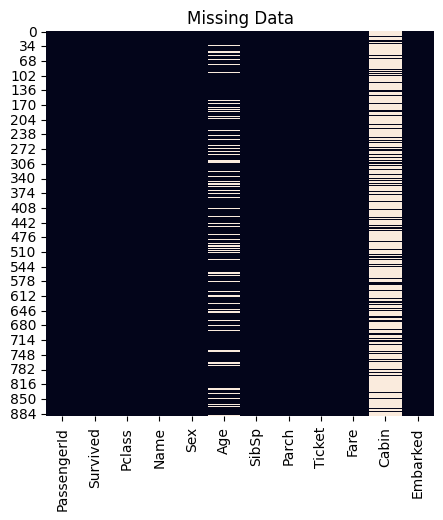

In [7]:
fig, ax = plt.subplots(figsize=(5,5))
plt.title("Missing Data")
sns.heatmap(train_df.isnull(), cbar=False)

We can see there are many fields are missing, and they are mostly age and cabin.

Now we dropp the rows that has empty fields

In [8]:
train_df = train_df.dropna(axis=0)

In [9]:
train_df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [10]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 183 entries, 1 to 889
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  183 non-null    int64  
 1   Survived     183 non-null    int64  
 2   Pclass       183 non-null    int64  
 3   Name         183 non-null    object 
 4   Sex          183 non-null    object 
 5   Age          183 non-null    float64
 6   SibSp        183 non-null    int64  
 7   Parch        183 non-null    int64  
 8   Ticket       183 non-null    object 
 9   Fare         183 non-null    float64
 10  Cabin        183 non-null    object 
 11  Embarked     183 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 18.6+ KB


We will remove the id, name, and Ticket as they are much more like an ID that doesn't affect to the model.
For sex, we will encode it like 0 or 1 for male or female. 


In [11]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
train_df["Sex"] = le.fit_transform(train_df["Sex"])

In [12]:
columns_to_drop = ['Name', 'Ticket', 'Cabin', 'Embarked']
train_df = train_df.drop(columns=columns_to_drop)

* Exploratory Data Analysis

In [13]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 183 entries, 1 to 889
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  183 non-null    int64  
 1   Survived     183 non-null    int64  
 2   Pclass       183 non-null    int64  
 3   Sex          183 non-null    int64  
 4   Age          183 non-null    float64
 5   SibSp        183 non-null    int64  
 6   Parch        183 non-null    int64  
 7   Fare         183 non-null    float64
dtypes: float64(2), int64(6)
memory usage: 12.9 KB


<Axes: >

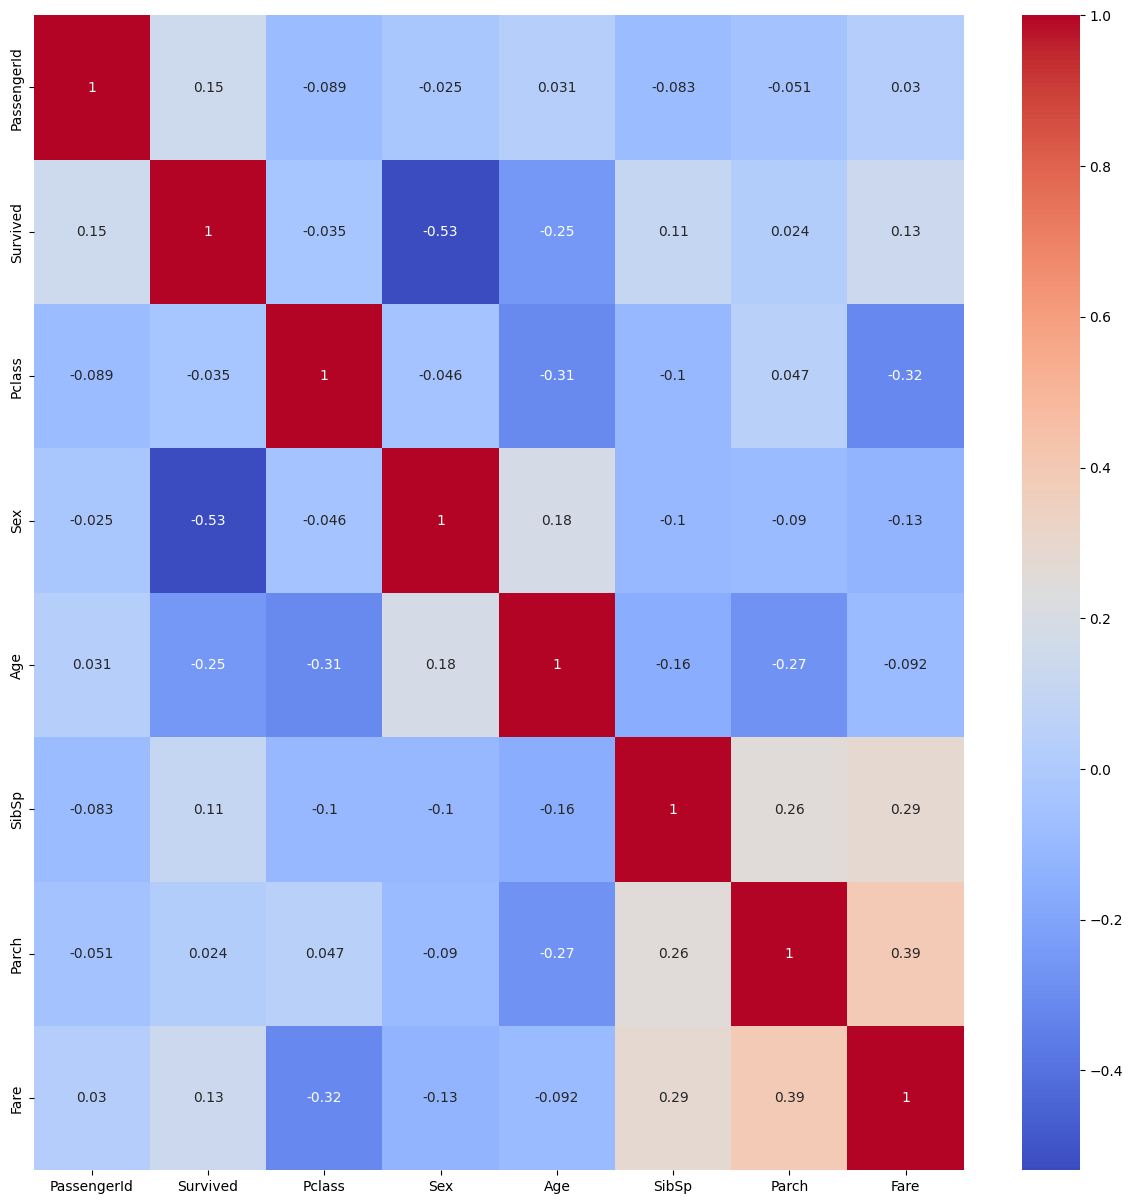

In [14]:
cor = train_df.corr()
plt.figure(figsize=(15, 15)) # width and height in inches

sns.heatmap(cor, annot=True, cmap= 'coolwarm')

Inspect relationships between features:

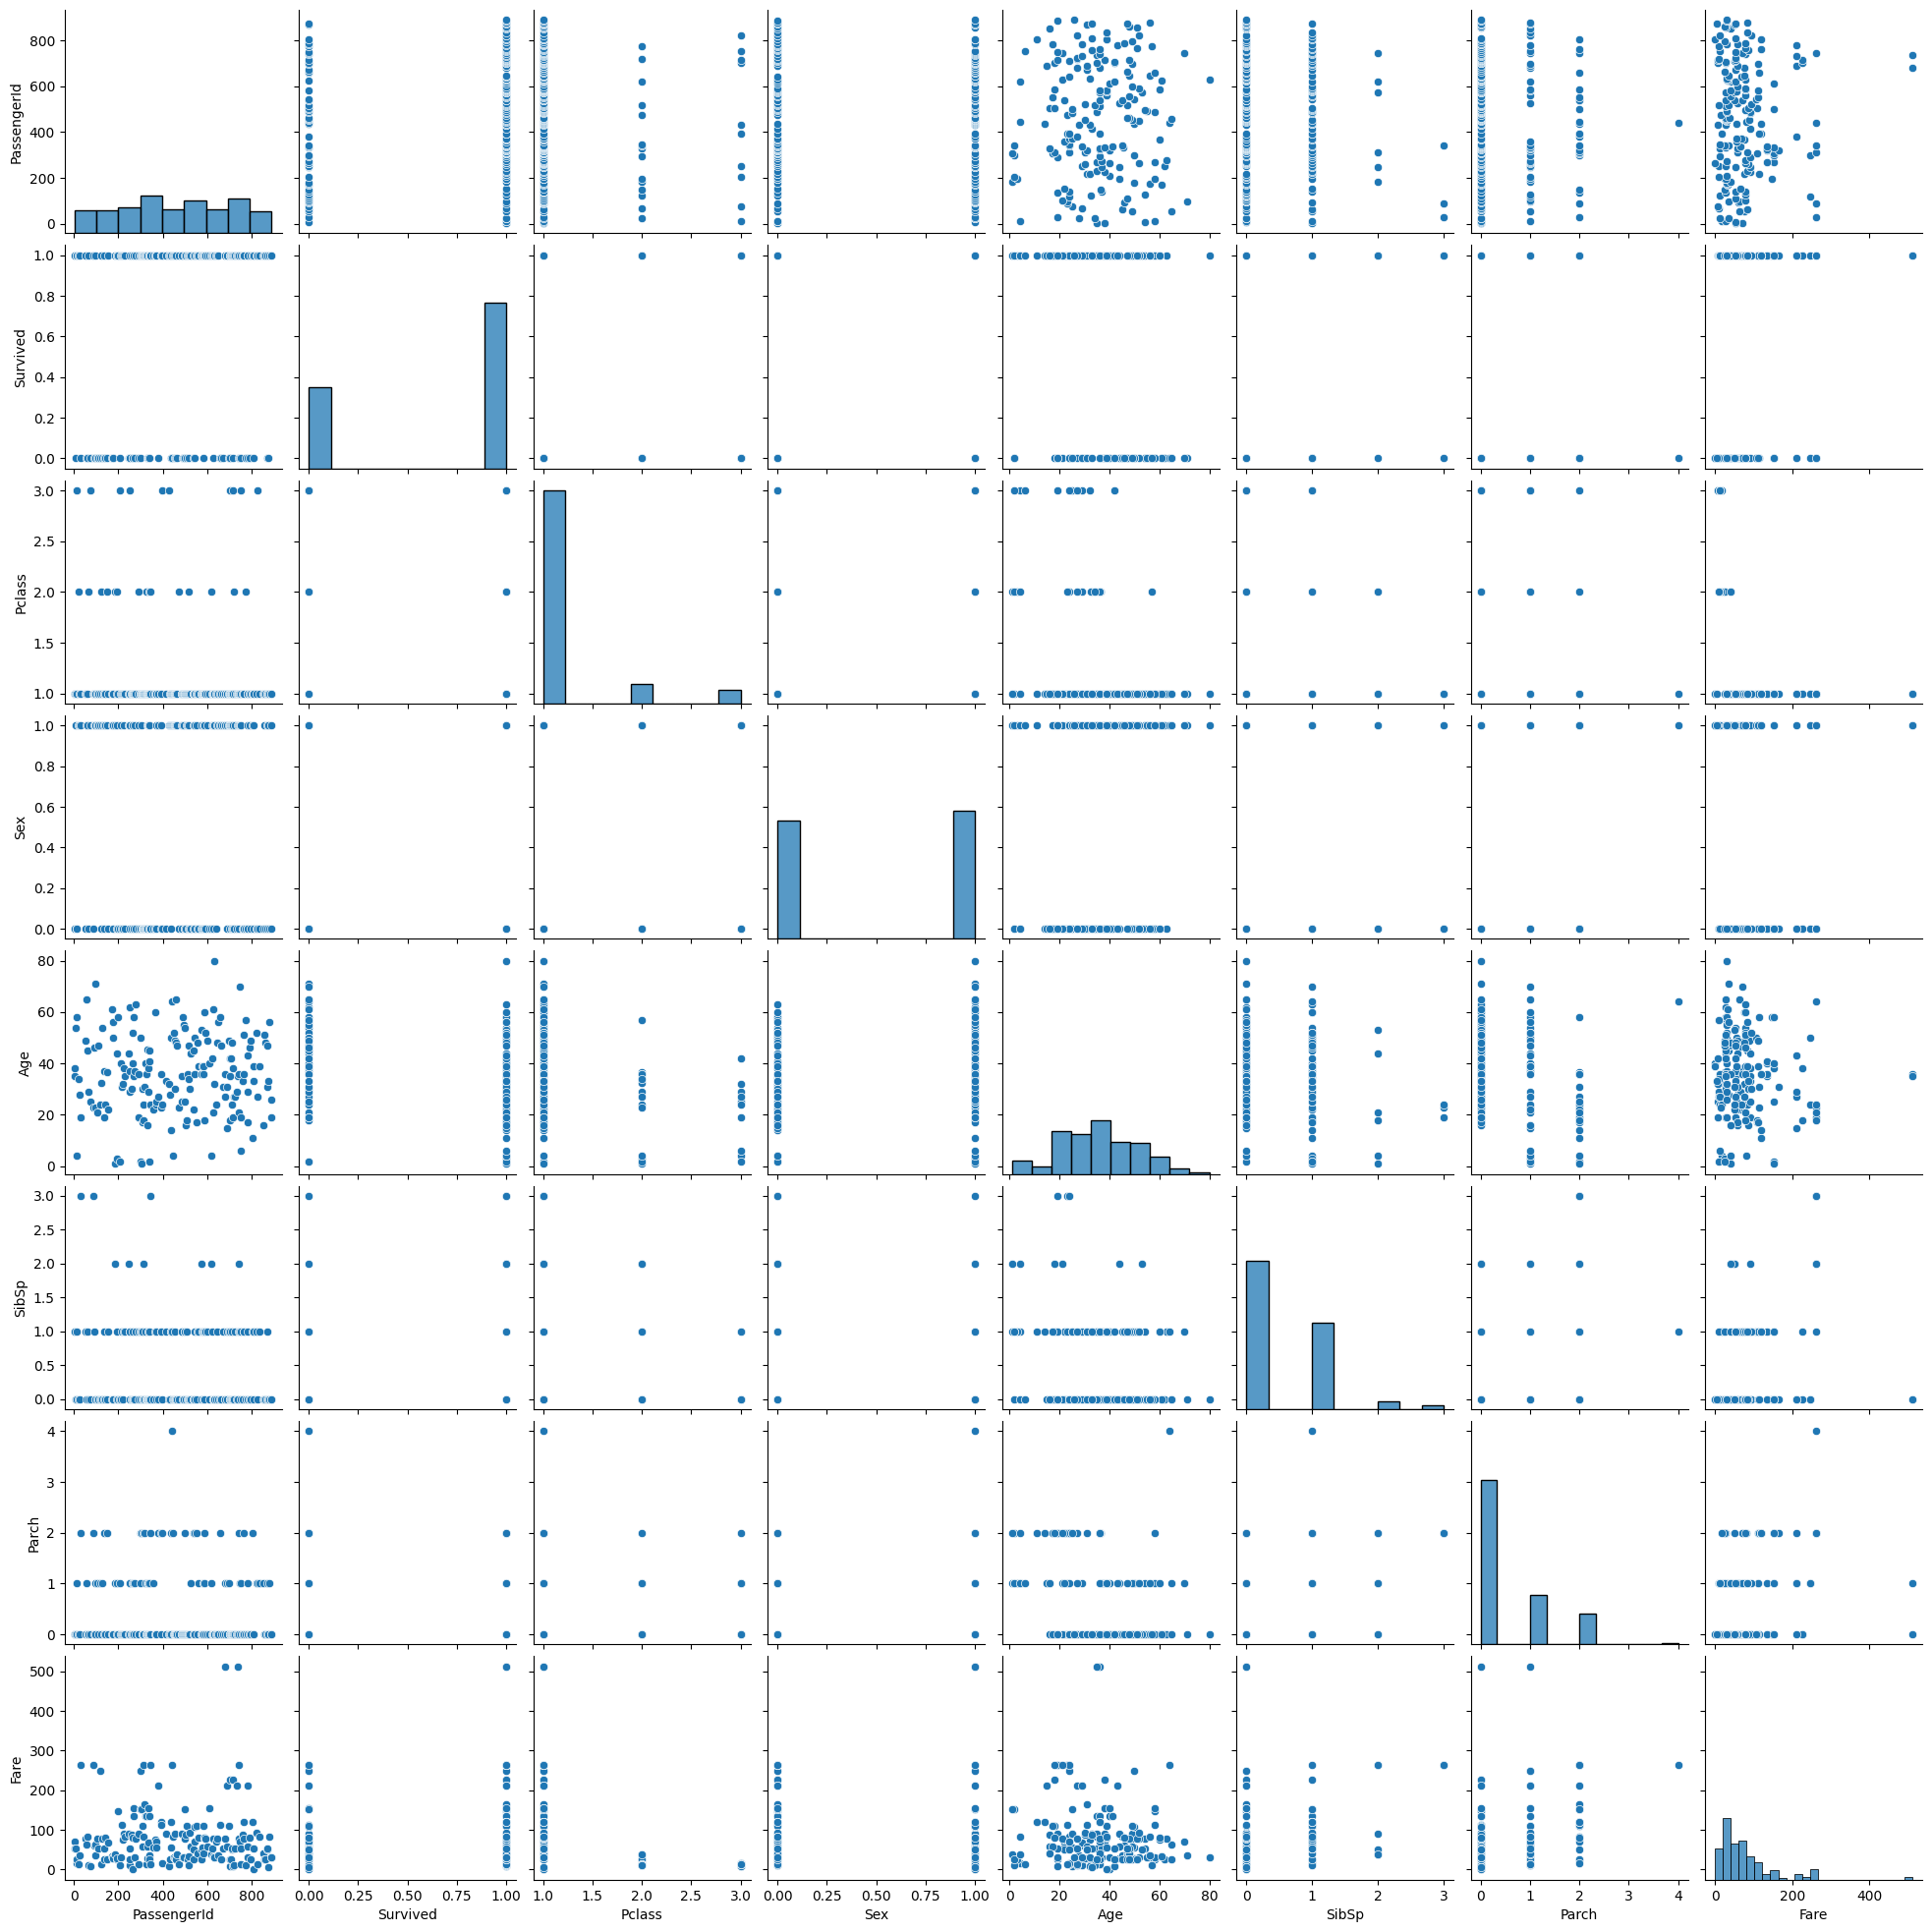

In [15]:
dr = train_df.iloc[:, : 10]
sns.pairplot(dr)

The data has 177 empty records in Age field, and 687 in Cabin. There are also 2 empty Embarked fields.
The solution is to pick the following fields: 
    "Pclass","Sex","Age","SibSp","Fare"

The reason is empty fields in Cabin don't affect the survival rate as when the ship sinks the passager or staff
followed the procedure to escape, so the location of the ship didn't matter, and it gave time for the passage and staff to escape.

As a result, we will remove the Cabin field.
For passenger ID, name, Embarked, Tick, and Parch, they are much more like a id record, so they are removed from the dataset for the training.

At the end, we will only move the follow 5 fields:
    "Pclass","Sex","Age","SibSp","Fare"
We dropped Fare fields as it has many empty fields and it has no effect for the training.

We also extract an X with those 5 fields, "Pclass","Sex","Age","SibSp", and"Fare", as a input dataset.
We extract Survived field as an Y out output dataset for the model.

In [16]:
features = ["Pclass","Sex","Age","SibSp","Fare"]
features_and_y = ["Pclass","Sex","Age","SibSp","Fare", "Survived"]
X = train_df[features]
y = train_df['Survived'];
X.head()


,Pclass,Sex,Age,SibSp,Fare
1,1,0,38.0,1,71.2833
3,1,0,35.0,1,53.1000
6,1,1,54.0,0,51.8625
10,3,0,4.0,1,16.7000
11,1,0,58.0,0,26.5500


We can see the fare are a outliers as they are like above 500.
We will remove them for training to give a much more stable result.

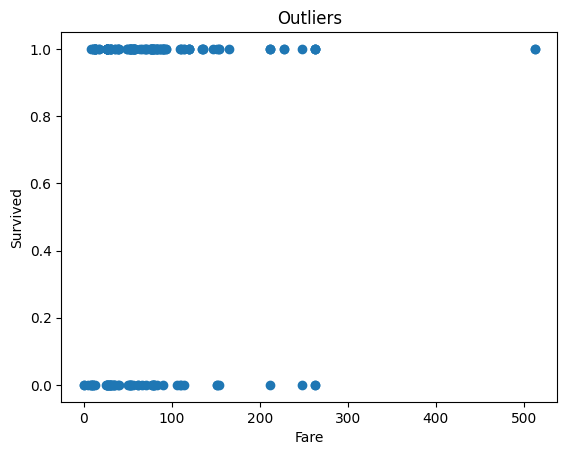

In [17]:
plt.scatter(X['Fare'], y)
plt.xlabel('Fare')
plt.ylabel('Survived')
plt.title("Outliers")
plt.show()

Use the mean of Fare to replace it.

In [18]:
fare_mean = X['Fare'].mean()
fare_mean

np.float64(78.68246885245901)

In [19]:
X[X['Fare'] > 500]


,Pclass,Sex,Age,SibSp,Fare
679,1,1,36.0,0,512.3292
737,1,1,35.0,0,512.3292


In [20]:
X.loc[679, 'Fare'] = fare_mean
X.loc[737, 'Fare'] = fare_mean

In [21]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 183 entries, 1 to 889
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Pclass  183 non-null    int64  
 1   Sex     183 non-null    int64  
 2   Age     183 non-null    float64
 3   SibSp   183 non-null    int64  
 4   Fare    183 non-null    float64
dtypes: float64(2), int64(3)
memory usage: 12.6 KB


Now we only have 183 rows after cleaning.

* Models

In [22]:
data_X, data_y = X.to_numpy(), y.to_numpy()   #convert them into numpy

Split the data into train and test set.

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(data_X, data_y, test_size=0.2)

In [24]:
X_train.shape, y_train.shape

((146, 5), (146,))

In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.base import clone 
from sklearn import tree
from sklearn.model_selection import train_test_split
import matplotlib.pylab as plt 
%matplotlib inline 

* Model 1, RandomForest

In [26]:
class RandomForest():
    
    def __init__(self, x, y, sample_sz, n_trees=500, n_features='sqrt', max_depth=5, min_samples_leaf=5):
        """
        Create a new random forest classifier.
        
        Args:
            x : Input Feature vector
            y : Corresponding Labels
            sample_sz : Sample size
            n_trees : Number of trees to ensemble
            n_features : Method to select subset of features 
            max_depth : Maximum depth of the trees in the ensemble
            min_sample_leaf : Minimum number of samples per leaf 
        """
        if n_features == 'sqrt':
            self.n_features = int(np.sqrt(x.shape[1]))
        elif n_features == 'log2':
            self.n_features = int(np.log2(x.shape[1]))
        else:
            self.n_features = n_features
        print(self.n_features, "shape: ",x.shape[1])  
        self.features_set = []
        self.x, self.y, self.sample_sz, self.max_depth, self.min_samples_leaf  = x, y, sample_sz, max_depth, min_samples_leaf
        self.trees = [self.create_tree(i) for i in range(n_trees)]

    def create_tree(self,i):
        """
        create a single decision tree classifier
        """
        
        idxs = np.random.permutation(len(self.y))[:self.sample_sz]
        idxs = np.asarray(idxs)

        f_idxs = np.random.permutation(self.x.shape[1])[:self.n_features]
        f_idxs = np.asarray(f_idxs)
        
        
        if i==0:
            self.features_set = np.array(f_idxs, ndmin=2)
        else:
            self.features_set = np.append(self.features_set, np.array(f_idxs,ndmin=2),axis=0)
        
        
        clf = DecisionTreeClassifier(
            max_depth=self.max_depth,
            min_samples_leaf=self.min_samples_leaf,
        )
        x, y = self.x[idxs][:, f_idxs], self.y[idxs]
        
        return clf.fit(x, y)
       
    def predict(self, x):
        
        
        y_pred = np.array([tree.predict(x[:, f_idxs]) 
                             for tree, f_idxs in zip(self.trees, self.features_set)])


        labels = np.unique(y_pred)
        label_to_id = {label: id for id, label in enumerate(labels)}



        voted_pred = np.zeros(x.shape[0], dtype=int)

        for i in range(x.shape[0]):

            votes = np.array([label_to_id[pred] 
                                    for pred in y_pred[:, i]])


            counts = np.bincount(votes)


            voted_c = np.argmax(counts)
            voted_pred[i] = labels[voted_c]

        return voted_pred
    
    def score(self, X, y):

        y_pred = self.predict(X)
        return np.mean(y_pred == y)


In [27]:
rf = RandomForest(X_train, y_train, sample_sz=int(0.8*len(y_train)))                                                         

2 shape:  5


In [28]:
print("Train accuracy:", rf.score(X_train, y_train))
print("Test accuracy:", rf.score(X_test, y_test))

Train accuracy: 0.8356164383561644
Test accuracy: 0.7837837837837838


Random Forest has a Training accuracy of 0.84 and Test accuracy of 0.78.
Result is not great.
Below is the Test error. Test Error is 0.22

In [29]:
print("Train error rate:", 1 - rf.score(X_train, y_train))
print("Test error: rate", 1 - rf.score(X_test, y_test))

Train error rate: 0.1643835616438356
Test error: rate 0.21621621621621623


In [30]:
class AdaBoost:
    def __init__(self, n_learners=20, base=DecisionTreeClassifier(max_depth=3), random_state=1234):
        """
        Create a new adaboost classifier.
         
        Args:
            N (int, optional): Number of weak learners in classifier.
            base (BaseEstimator, optional): Your general weak learner 
            random_state (int, optional): set random generator.  needed for unit testing. 

        Attributes:
            base (estimator): Your general weak learner 
            n_learners (int): Number of weak learners in classifier.
            alpha (ndarray): Coefficients on weak learners. 
            learners (list): List of weak learner instances. 
        """
        
        np.random.seed(42)
        
        self.n_learners = n_learners 
        self.base = base
        self.alpha = np.zeros(self.n_learners)
        self.learners = []
        
    def fit(self, X_train, y_train):
        """
        Train AdaBoost classifier on data. Sets alphas and learners. 
        
        Args:
            X_train (ndarray): [n_samples x n_features] ndarray of training data   
            y_train (ndarray): [n_samples] ndarray of data 
        """

        w = np.ones(len(y_train), dtype = np.longdouble)
        w /= np.sum(w) 
        
        for k in range(self.n_learners):
            h = clone(self.base)
            h.fit(X_train, y_train, sample_weight=w)
            y_pred = h.predict(X_train)
            
            err = self.error_rate(y_train, y_pred, w)
            
            #err = np.sum(w * (y_pred != y_train)) / np.sum(w)
            self.alpha[k] = 0.5 * np.log((1 - err)/err)
            #print("debug: ",self.alpha[k])
            self.learners.append(h)
            
            
            w = w*np.exp(-self.alpha[k] * y_train * y_pred)
            w = w/np.sum(w)
        return self  
            
    def error_rate(self, y_true, y_pred, weights):

        misclassified = np.not_equal(y_true, y_pred).astype(int)
        error_rate = np.sum(weights * misclassified) / np.sum(weights)
    
        return error_rate
        
    def predict(self, X):
        """
        Adaboost prediction for new data X.
        
        Args:
            X (ndarray): [n_samples x n_features] ndarray of data 
            
        Returns: 
            yhat (ndarray): [n_samples] ndarray of predicted labels {-1,1}
        """

        yhat = np.zeros(X.shape[0])
        
        preds = np.array([l.predict(X) for l in self.learners])

        votes = np.dot(self.alpha, preds)
        yhat = np.sign(votes)
        return yhat
    
    def score(self, X, y):
        """
        Computes prediction accuracy of classifier.  
        
        Args:
            X (ndarray): [n_samples x n_features] ndarray of data 
            y (ndarray): [n_samples] ndarray of true labels  
            
        Returns: 
            Prediction accuracy (between 0.0 and 1.0).
        """

        y_pred = self.predict(X)          
        return np.mean(y == y_pred)          
    
    def staged_score(self, X, y):
        """
        Computes the ensemble score after each iteration of boosting 
        for monitoring purposes, such as to determine the score on a 
        test set after each boost.
        
        Args:
            X (ndarray): [n_samples x n_features] ndarray of data 
            y (ndarray): [n_samples] ndarray of true labels  
            
        Returns: 
            scores (ndarary): [n_learners] ndarray of scores 
        """

        scores = []
        
        scores= []  #accuracies
        pred = np.zeros(X.shape[0])
        for a, l in zip(self.alpha, self.learners):
            pred = pred+a * l.predict(X)
            scores.append(np.mean(y==np.sign(pred)))
        
        
        return np.array(scores)        


In [31]:
clf = AdaBoost(n_learners=1400, base=DecisionTreeClassifier(max_depth=1))
clf.fit(X_train, y_train)

In [32]:
sc = clf.score(X_train, y_train) #
print("train accuracy: ",sc)
print("train error: ",1 - sc)

train accuracy:  0.7123287671232876
train error:  0.28767123287671237


In [33]:
sc = clf.score(X_test, y_test) #
print("test accuracy: ",sc)
print("test error: ",1 - sc)

test accuracy:  0.6756756756756757
test error:  0.32432432432432434


The result is not good as it has 0.68 accuracy.

* Regulzation

In [34]:
# plot misclassification error for train and test sets for regulzation

sc = clf.staged_score(X_test, y_test)

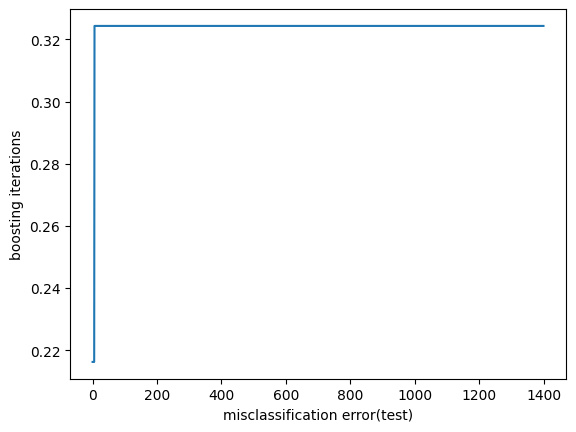

In [35]:
import matplotlib.pyplot as plt
import numpy as np

xpoints = np.array([x for x in range(len(sc))])
ypoints = 1-sc

plt.plot(xpoints, ypoints)
plt.xlabel("misclassification error(test)")
plt.ylabel("boosting iterations")
plt.show()

We can see the boosting are great in the beginning. The result should be fine.

* XGBoost Model

In [36]:
!pip install xgboost


[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: pip install --upgrade pip


In [37]:
from xgboost import XGBClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


In [38]:
model = XGBClassifier(
    n_estimators=100,  
    max_depth=3,       
    learning_rate=0.1,
    random_state=42
)
model.fit(X_train, y_train) 

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [39]:
y_pred = model.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.2f}")

Test Accuracy: 0.78


In [40]:
print(f"Test Error Rate: {1 - accuracy_score(y_test, y_pred):.2f}")

Test Error Rate: 0.22


XGBClassifier Cross

Using the corss validation score to see the result better.

In [41]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(XGBClassifier(), X, y, cv=5, scoring='accuracy')
print(f"CV Accuracy: {scores.mean():.2f} (±{scores.std():.2f})")

CV Accuracy: 0.75 (±0.08)


Result:
75% of validation samples were correctly classified. The model but not excellent.

As a result, picking XGBoost Model as our final model to see improvement.

* Hyperparameter Tuning

GridSearchCV

In [42]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [50, 100, 200]
}

grid = GridSearchCV(XGBClassifier(), param_grid, cv=10, scoring='accuracy')
grid.fit(X_train, y_train)
print(f"Best params: {grid.best_params_}")

Best params: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 50}


In [43]:
print(f"Test accuracy: {grid.score(X_test, y_test):.2f}")

Test accuracy: 0.81


In [44]:
y_pred = grid.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.2f}")

Test Accuracy: 0.81


* Results and Analysis
It looks like the XGboost has the best result with 0.81. AdaBoost is 0.68. Random Forest is 0.78

Discussion and Conclusion:
It looks like for a predicting the surviual chance my the feature of the passagers and the staffs.
It still best to use the spliting feature way to predict. This used the Random forest as the second
best result(0.78 accuracy). Than a better version of it, XGBoost gives even a better result, 0.81.